<a href="https://colab.research.google.com/github/NanC-Nabil/NTI/blob/main/Task1Session6_NTI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

In [2]:
# Load Dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Add Channel Dimension
X_train = X_train[..., None]
X_test = X_test[..., None]

print(X_train.shape)
print(X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [3]:
def inception_module(x,
                     f1,
                     f3_in, f3_out,
                     f5_in, f5_out,
                     f_pool):

    # Path 1 : 1x1 Conv
    path1 = layers.Conv2D(f1,
                          (1,1),
                          padding='same',
                          activation='relu')(x)

    # Path 2 : 1x1 -> 3x3
    path2 = layers.Conv2D(f3_in,
                          (1,1),
                          padding='same',
                          activation='relu')(x)

    path2 = layers.Conv2D(f3_out,
                          (3,3),
                          padding='same',
                          activation='relu')(path2)

    # Path 3 : 1x1 -> 5x5
    path3 = layers.Conv2D(f5_in,
                          (1,1),
                          padding='same',
                          activation='relu')(x)

    path3 = layers.Conv2D(f5_out,
                          (5,5),
                          padding='same',
                          activation='relu')(path3)

    # Path 4 : MaxPool -> 1x1
    path4 = layers.MaxPooling2D(pool_size=(3,3),
                                strides=(1,1),
                                padding='same')(x)

    path4 = layers.Conv2D(f_pool,
                          (1,1),
                          padding='same',
                          activation='relu')(path4)

    # Concatenate
    output = layers.concatenate(
        [path1, path2, path3, path4],
        axis=-1
    )

    return output

In [4]:
inputs = layers.Input(shape=(28,28,1))

# Initial Convolution
x = layers.Conv2D(32,
                  (3,3),
                  padding='same',
                  activation='relu')(inputs)

x = layers.MaxPooling2D((2,2))(x)

# First Inception
x = inception_module(
    x,
    f1=32,
    f3_in=32,
    f3_out=64,
    f5_in=16,
    f5_out=32,
    f_pool=32
)

x = layers.MaxPooling2D((2,2))(x)

# Second Inception
x = inception_module(
    x,
    f1=64,
    f3_in=64,
    f3_out=96,
    f5_in=32,
    f5_out=48,
    f_pool=64
)

# Global Average Pooling
x = layers.GlobalAveragePooling2D()(x)

# Dropout
x = layers.Dropout(0.4)(x)

# Output
outputs = layers.Dense(10,
                       activation='softmax')(x)

model = Model(inputs, outputs)

In [5]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 28, 28,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 14, 14,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 14, 14,    │      1,056 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 14, 14,    │        528 │ max_pooling2d[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 14, 14,    │          0 │ max_pooling2d[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 14, 14,    │      1,056 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 14, 14,    │     18,496 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 14, 14,    │     12,832 │ conv2d_4[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 14, 14,    │      1,056 │ max_pooling2d_1[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 14, 14,    │          0 │ conv2d_1[0][0],   │
│ (Concatenate)       │ 160)              │            │ conv2d_3[0][0],   │
│                     │                   │            │ conv2d_5[0][0],   │
│                     │                   │            │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 7, 7, 160) │          0 │ concatenate[0][0] │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 7, 7, 64)  │     10,304 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 7, 7, 32)  │      5,152 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 7, 7, 160) │          0 │ max_pooling2d_2[… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 7, 7, 64)  │     10,304 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 7, 7, 96)  │     55,392 │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 167,978 (656.16 KB)

 Trainable params: 167,978 (656.16 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.6656 - loss: 0.9008 - val_accuracy: 0.7795 - val_loss: 0.5941
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7945 - loss: 0.5686 - val_accuracy: 0.8281 - val_loss: 0.4743
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8277 - loss: 0.4795 - val_accuracy: 0.8519 - val_loss: 0.4100
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8471 - loss: 0.4236 - val_accuracy: 0.8667 - val_loss: 0.3659
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8611 - loss: 0.3849 - val_accuracy: 0.8773 - val_loss: 0.3387
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8714 - loss: 0.3585 - val_accuracy: 0.8861 - val_loss: 0.3183
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8801 - loss: 0.3307 - val_accuracy: 0.8892 - val_loss: 0.3074
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8860 - loss: 0.3163 - val_accuracy: 

In [8]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Accuracy :", test_acc)
print("Test Loss :", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8983 - loss: 0.2805
Test Accuracy : 0.8982999920845032
Test Loss : 0.28049904108047485


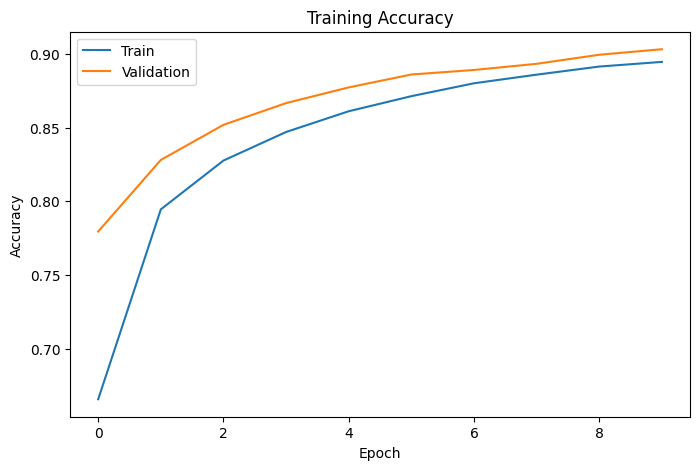

In [9]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")

plt.legend()
plt.show()